<a href="https://colab.research.google.com/github/JoGabTasca/ML/blob/main/AP2_ML_AutoGluon_JoaoGabriel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AP2 — Projeto Profissional de Aprendizado de Máquina com AutoGluon

**Disciplina:** Machine Learning  
**Aluno:** João Gabriel Tasca  
**Instituição:** IBMEC-RJ Barra  
**Professor:** Alvaro Riz de Barros

## 1. Formulação do Problema

### 1.1 Qual problema será resolvido?

Uma instituição bancária portuguesa realizou campanhas de marketing direto por telefone com o objetivo de oferecer um produto financeiro chamado **depósito a prazo**. O desafio é construir um modelo preditivo capaz de identificar, com base nas características do cliente e nos dados da campanha, se ele irá ou não aceitar a oferta.

Esse tipo de problema é extremamente relevante no setor financeiro, pois campanhas de marketing têm custo operacional elevado (tempo de ligação, mão de obra de agentes) e a capacidade de segmentar clientes com maior propensão à adesão gera ganho direto de eficiência.

### 1.2 Variável-alvo

A variável-alvo é `contratou`, que indica se o cliente assinou ou não o depósito a prazo.

### 1.3 Classes do problema

| Valor | Significado |
|-------|-------------|
| `sim` | O cliente assinou o depósito a prazo |
| `nao` | O cliente não assinou o depósito a prazo |

O problema é de **classificação binária**: o modelo precisa escolher entre duas classes mutuamente exclusivas.

### 1.4 Por que é um problema de classificação supervisionada?

- **Supervisionado:** temos exemplos históricos com o resultado conhecido (se o cliente aceitou ou não). O modelo aprende a partir dessas observações rotuladas.
- **Classificação:** a saída é uma categoria discreta (`sim` / `nao`), não um valor contínuo. Diferente de regressão, onde se prevê um número.

### 1.5 Como esse modelo poderia ser usado por uma instituição financeira?

O modelo poderia ser integrado ao CRM da instituição para priorizar contatos antes de cada campanha. Em vez de ligar para toda a base de clientes, o banco focaria nos perfis com maior probabilidade de adesão — reduzindo custo de operação, diminuindo a fricção com clientes desinteressados e aumentando a taxa de conversão geral da campanha.

**Exemplos de uso prático:**
- Criar um *score* de propensão por cliente atualizado mensalmente.
- Direcionar clientes de alto *score* para o canal telefônico e os demais para canais digitais mais baratos.
- Monitorar grupos que o modelo considera "difíceis" para criar abordagens personalizadas.

### 1.6 Custo dos erros: Falso Positivo vs. Falso Negativo

**Falso Positivo (FP):** o modelo prevê que o cliente aceitará, mas ele recusa.  
→ Custo: O banco gasta recursos de ligação com um cliente que não vai converter. Esse custo é real, mas relativamente baixo (uma ligação perdida).

**Falso Negativo (FN):** o modelo prevê que o cliente não aceitará, mas ele aceitaria.  
→ Custo: O banco perde uma oportunidade de receita — um cliente que teria aceitado a oferta não é contatado. Dependendo do valor do produto financeiro (depósito a prazo), essa perda pode ser significativa.

**Conclusão sobre o erro mais grave:**
Em campanhas de captação como esta, o **falso negativo tende a ser mais prejudicial**, pois representa perda direta de receita. O objetivo do modelo deve ser maximizar a identificação dos clientes que realmente aceitariam (alto Recall), mesmo que isso implique ligar para alguns que não aceitarão. Portanto, a **métrica principal será o F1-score**, que equilibra Precision e Recall, com atenção especial ao Recall.

## 2. Instalação das Bibliotecas (via uv)

In [ ]:
# Instalação do uv (gerenciador de pacotes rápido)
!pip install uv -q

# Instalação das dependências via uv
!uv pip install autogluon pandas numpy matplotlib seaborn scikit-learn --system -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.1/25.1 MB 14.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from autogluon.tabular import TabularPredictor

# Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 3. Carregamento e Análise Exploratória dos Dados (EDA)

In [ ]:
url = "https://raw.githubusercontent.com/alvaroriz/datascience_datasets/refs/heads/main/marketing_bancario.csv"
df = pd.read_csv(url, sep=';')
print(f'Base carregada: {df.shape[0]} linhas x {df.shape[1]} colunas')
df.head()

Base carregada: 45211 linhas x 17 colunas


,idade,profissao,estado_civil,escolaridade,inadimplente,saldo,emprestimo_habitacional,emprestimo_pessoal,tipo_contato,dia,mes,duracao,contatos_campanha,dias_ultimo_contato,contatos_anteriores,resultado_anterior,contratou
0,58,gerencia,casado,superior,nao,2143,sim,nao,desconhecido,5,mai,261,1,-1,0,desconhecido,nao
1,44,tecnico,solteiro,medio,nao,29,sim,nao,desconhecido,5,mai,151,1,-1,0,desconhecido,nao
2,33,empresario,casado,medio,nao,2,sim,sim,desconhecido,5,mai,76,1,-1,0,desconhecido,nao
3,47,operario,casado,desconhecido,nao,1506,sim,nao,desconhecido,5,mai,92,1,-1,0,desconhecido,nao
4,33,desconhecido,solteiro,desconhecido,nao,1,nao,nao,desconhecido,5,mai,198,1,-1,0,desconhecido,nao


### 3.1 Dimensões e Tipos de Variáveis

In [ ]:
print('=== Informações Gerais ===')
print(f'Linhas: {df.shape[0]}')
print(f'Colunas: {df.shape[1]}')
print()
print('=== Tipos das variáveis ===')
print(df.dtypes)

=== Informações Gerais ===
Linhas: 45211
Colunas: 17

=== Tipos das variáveis ===
idade                       int64
profissao                  object
estado_civil               object
escolaridade               object
inadimplente               object
saldo                       int64
emprestimo_habitacional    object
emprestimo_pessoal         object
tipo_contato               object
dia                         int64
mes                        object
duracao                     int64
contatos_campanha           int64
dias_ultimo_contato         int64
contatos_anteriores         int64
resultado_anterior         object
contratou                  object
dtype: object


### 3.2 Valores Ausentes

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Ausentes': missing, '% Ausentes': missing_pct})
missing_df = missing_df[missing_df['Ausentes'] > 0]

if missing_df.empty:
    print('Nenhum valor ausente encontrado na base.')
else:
    print(missing_df)

Nenhum valor ausente encontrado na base.


### 3.3 Distribuição da Variável-Alvo `y`

=== Distribuição da variável-alvo ===
           Contagem  Percentual (%)
contratou                          
nao           39922            88.3
sim            5289            11.7


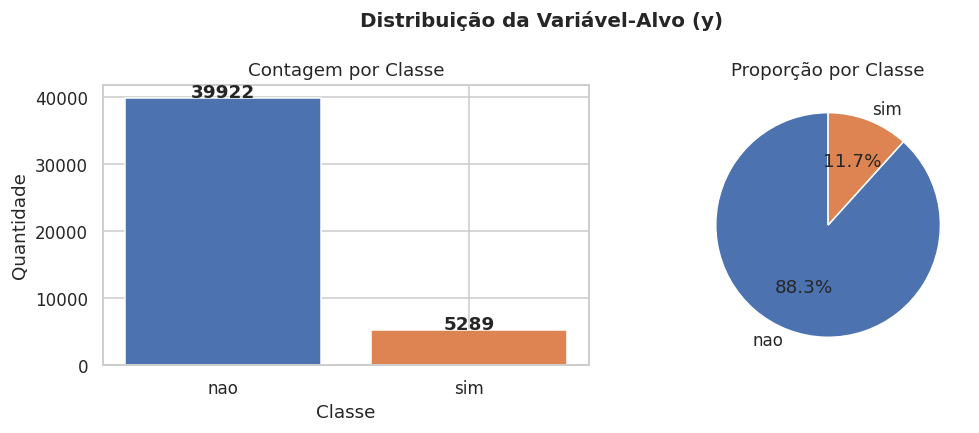

In [ ]:
contagem = df['contratou'].value_counts()
percentual = df['contratou'].value_counts(normalize=True).mul(100).round(2)

print('=== Distribuição da variável-alvo ===')
print(pd.DataFrame({'Contagem': contagem, 'Percentual (%)': percentual}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(contagem.index, contagem.values, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Contagem por Classe')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Quantidade')
for i, v in enumerate(contagem.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(contagem.values, labels=contagem.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90)
axes[1].set_title('Proporção por Classe')

plt.suptitle('Distribuição da Variável-Alvo (y)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretação:** A base é claramente **desbalanceada**. A classe `nao` (não aceitou) representa a grande maioria dos registros (~88,3%), enquanto `sim` (aceitou) é minoritária (~11,7%). Isso é esperado em campanhas de marketing direto, onde a taxa de conversão costuma ser baixa (tipicamente entre 5% e 15%). Esse desbalanceamento impacta diretamente a escolha de métricas: **a acurácia sozinha não é suficiente**, pois um modelo que prevê sempre `nao` já alcançaria ~88% de acurácia sem aprender nada útil. Por isso, usaremos **F1-score** e **ROC-AUC** como métricas centrais.

### 3.4 Análise das Variáveis Numéricas

In [ ]:
num_cols = df.select_dtypes(include='number').columns.tolist()
print('Variáveis numéricas:', num_cols)
df[num_cols].describe().round(2)

Variáveis numéricas: ['idade', 'saldo', 'dia', 'duracao', 'contatos_campanha', 'dias_ultimo_contato', 'contatos_anteriores']


,idade,saldo,dia,duracao,contatos_campanha,dias_ultimo_contato,contatos_anteriores
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,40.94,1362.27,15.81,258.16,2.76,40.20,0.58
std,10.62,3044.77,8.32,257.53,3.10,100.13,2.30
min,18.00,-8019.00,1.00,0.00,1.00,-1.00,0.00
25%,33.00,72.00,8.00,103.00,1.00,-1.00,0.00
50%,39.00,448.00,16.00,180.00,2.00,-1.00,0.00
75%,48.00,1428.00,21.00,319.00,3.00,-1.00,0.00
max,95.00,102127.00,31.00,4918.00,63.00,871.00,275.00


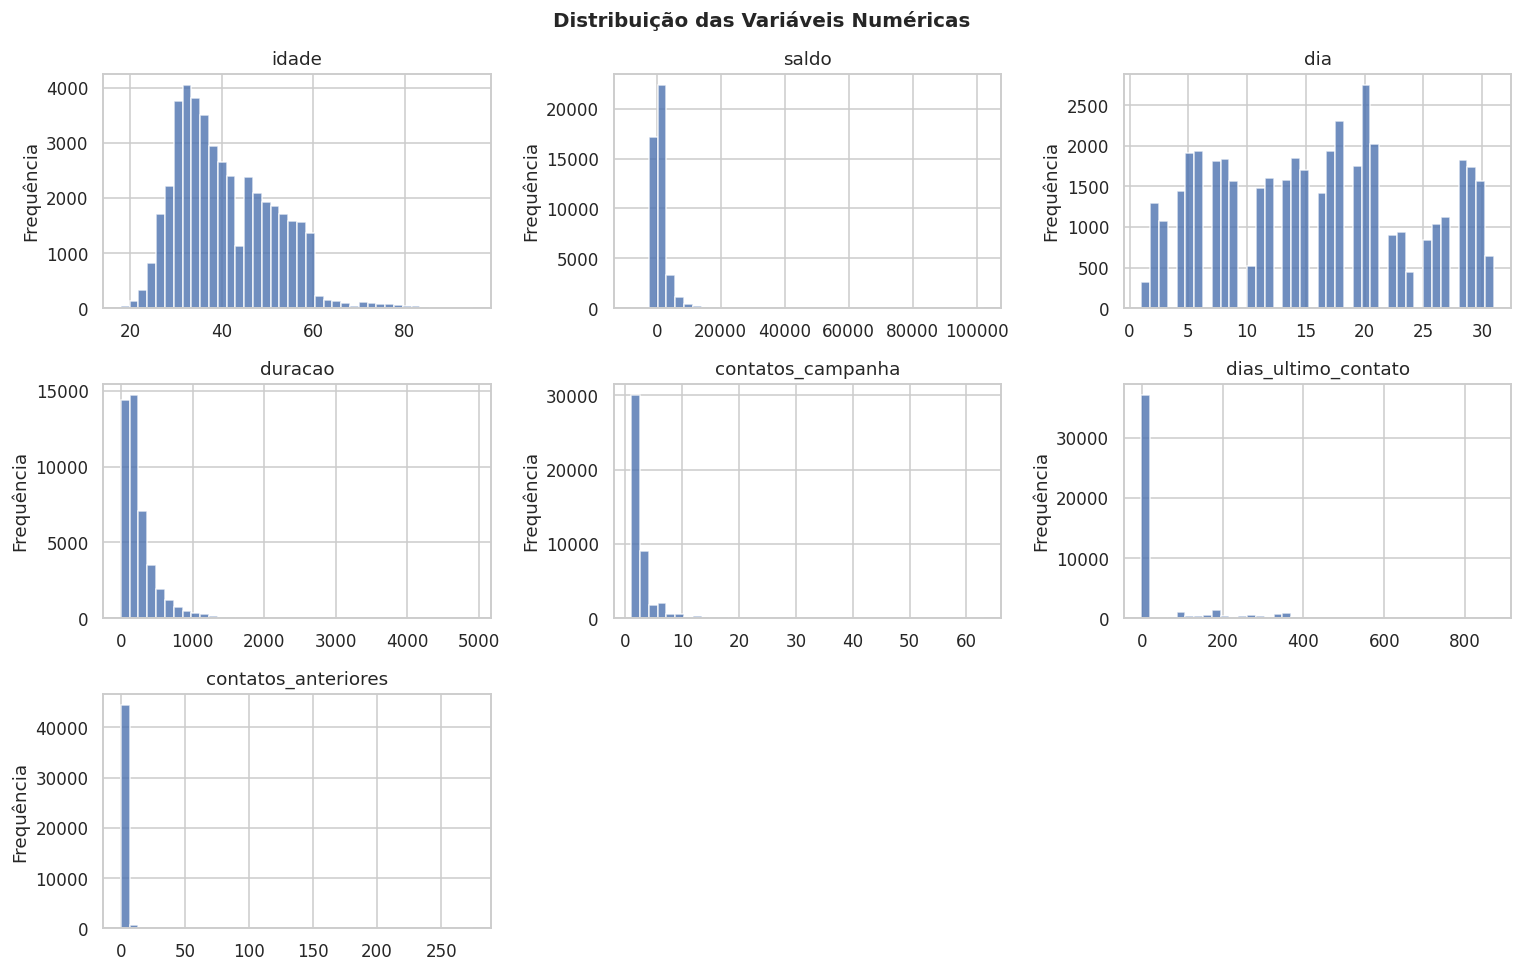

In [ ]:
n = len(num_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='#4C72B0', edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_ylabel('Frequência')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuição das Variáveis Numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretação:**
- `idade`: distribuição concentrada entre 25 e 60 anos, com cauda longa à direita. Clientes mais velhos podem ter maior propensão a produtos de poupança.
- `saldo`: alta variabilidade; presença de valores negativos (clientes com saldo negativo) e outliers muito elevados.
- `duracao`: duração da última ligação telefônica — **variável suspeita de data leakage** (detalhada na Seção 4).
- `contatos_campanha`: maioria dos clientes foi contactada apenas 1 ou 2 vezes.
- `dias_ultimo_contato`: valor -1 indica que o cliente não foi contatado em campanha anterior (valor especial).
- `contatos_anteriores`: maioria dos clientes não tinha contato anterior (valor 0).

### 3.5 Análise das Variáveis Categóricas

In [ ]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'contratou']
print('Variáveis categóricas:', cat_cols)

for col in cat_cols:
    print(f'\n{col}: {df[col].nunique()} categorias')
    print(df[col].value_counts().head(6))

Variáveis categóricas: ['profissao', 'estado_civil', 'escolaridade', 'inadimplente', 'emprestimo_habitacional', 'emprestimo_pessoal', 'tipo_contato', 'mes', 'resultado_anterior']

profissao: 12 categorias
profissao
operario          9732
gerencia          9458
tecnico           7597
administrativo    5171
servicos          4154
aposentado        2264
Name: count, dtype: int64

estado_civil: 3 categorias
estado_civil
casado        27214
solteiro      12790
divorciado     5207
Name: count, dtype: int64

escolaridade: 4 categorias
escolaridade
medio           23202
superior        13301
fundamental      6851
desconhecido     1857
Name: count, dtype: int64

inadimplente: 2 categorias
inadimplente
nao    44396
sim      815
Name: count, dtype: int64

emprestimo_habitacional: 2 categorias
emprestimo_habitacional
sim    25130
nao    20081
Name: count, dtype: int64

emprestimo_pessoal: 2 categorias
emprestimo_pessoal
nao    37967
sim     7244
Name: count, dtype: int64

tipo_contato: 3 categoria

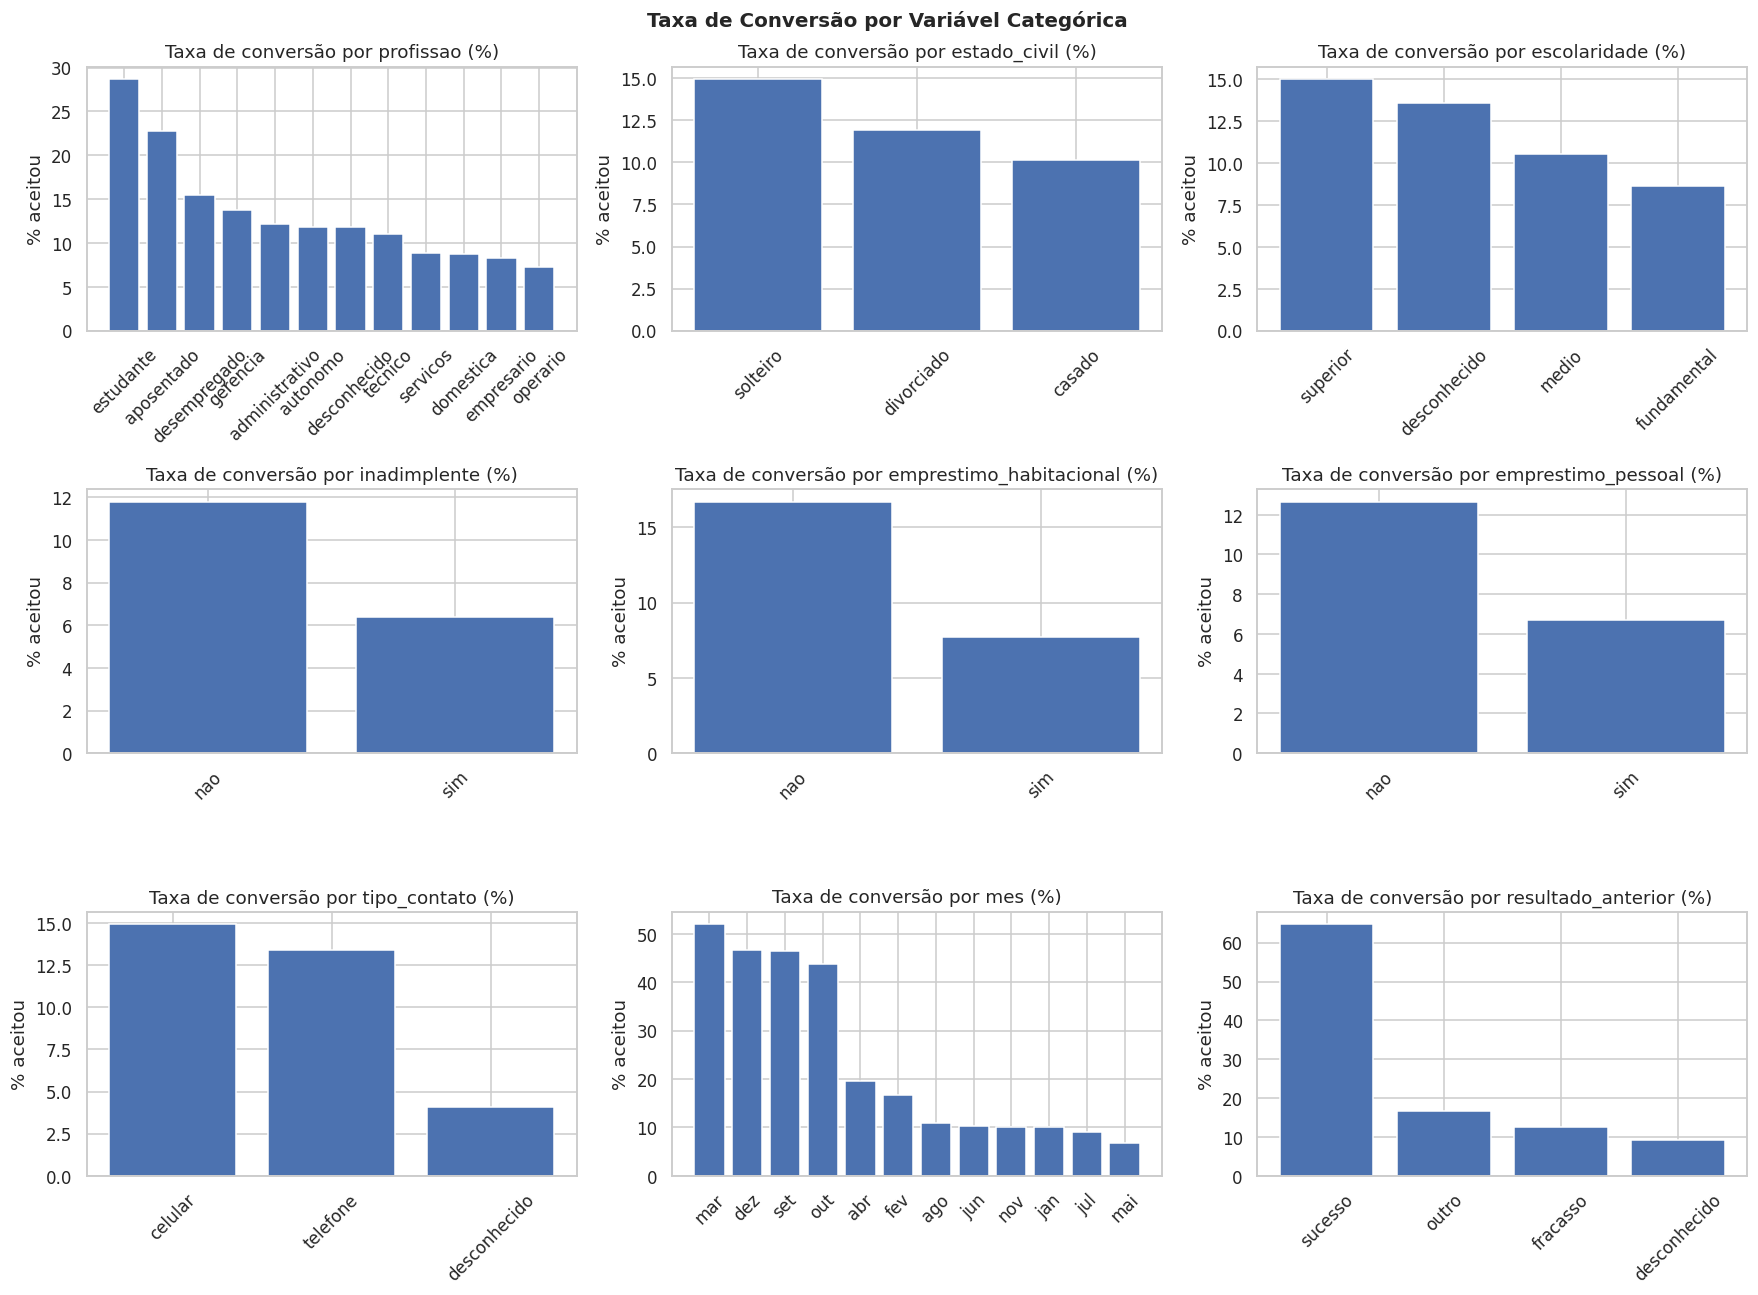

In [ ]:
# Taxa de conversão por variável categórica
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols[:9]):
    taxa = df.groupby(col)['contratou'].apply(lambda x: (x == 'sim').mean() * 100)
    taxa = taxa.sort_values(ascending=False)
    axes[i].bar(taxa.index, taxa.values, color='#4C72B0', edgecolor='white')
    axes[i].set_title(f'Taxa de conversão por {col} (%)')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('% aceitou')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Taxa de Conversão por Variável Categórica', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretação:** As taxas de conversão variam significativamente entre categorias, indicando que as variáveis categóricas têm poder preditivo. Por exemplo, clientes com certos tipos de trabalho ou com resultado positivo em campanhas anteriores (`resultado_anterior = sucesso`) tendem a aceitar a oferta com muito mais frequência. O mês do contato também apresenta variação expressiva, sugerindo sazonalidade financeira.

## 4. ⚠️ Identificação de Data Leakage — Variável `duracao`

A variável `duracao` representa a **duração em segundos da última ligação telefônica** com o cliente.

### Por que ela é suspeita de data leakage?

A duração da ligação só é conhecida **após** a ligação ter acontecido — e naturalmente, ligações mais longas tendem a indicar que o cliente estava mais engajado, potencialmente aceitando a oferta no final. Ou seja:

- Se o cliente assinou, a ligação provavelmente foi longa (muito tempo explicando o produto, formalizando).
- Se o cliente recusou rapidamente, a duração foi curta.

Isso significa que `duracao` é **consequência da variável-alvo**, não causa. Em um cenário real de predição (antes de fazer a ligação), esse valor **não estaria disponível**. Incluí-lo no modelo seria como "trapacear": o modelo aprenderia uma correlação artificial que não existiria no momento em que a predição precisa ser feita.

### Estratégia adotada

Treinaremos e avaliaremos **dois cenários**:
1. **Com `duracao`**: para mostrar o impacto inflacionado da variável vazada.
2. **Sem `duracao`**: o modelo realista, que poderia ser usado antes da campanha.

A comparação entre os dois será incluída na tabela final de resultados.

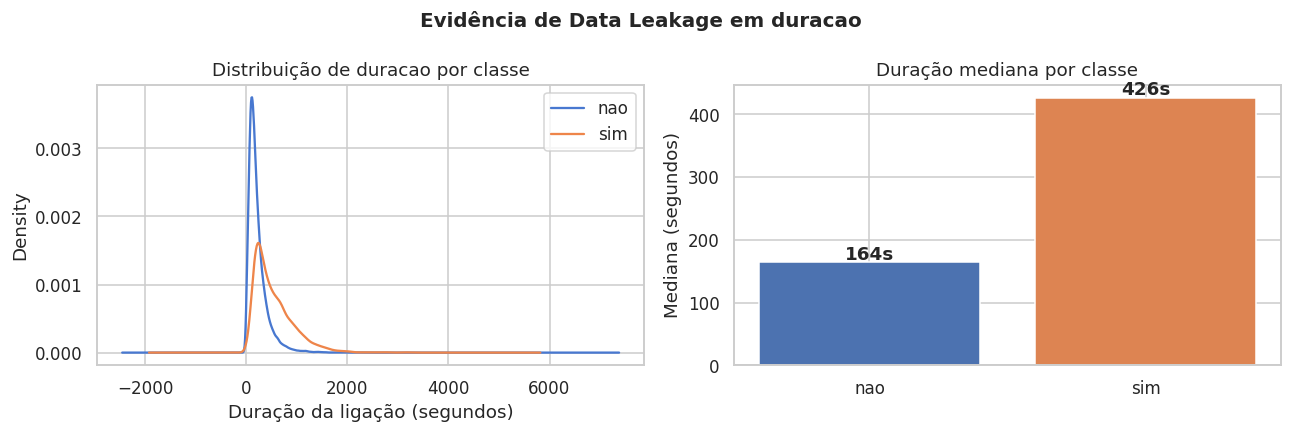

Correlação de duracao com contratou (encodado):
0.3945

Interpretação: Correlação de ~0.39 é alta para uma variável de campanha.
Clientes que aceitaram têm duração mediana ~426s; os que recusaram, ~164s.
Essa diferença não existiria no momento da predição (antes da ligação).


In [ ]:
# Evidência visual do data leakage: distribuição de duracao por classe
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.groupby('contratou')['duracao'].plot.kde(ax=axes[0], legend=True)
axes[0].set_title('Distribuição de duracao por classe')
axes[0].set_xlabel('Duração da ligação (segundos)')

medians = df.groupby('contratou')['duracao'].median()
axes[1].bar(medians.index, medians.values, color=['#4C72B0', '#DD8452'])
axes[1].set_title('Duração mediana por classe')
axes[1].set_ylabel('Mediana (segundos)')
for i, v in enumerate(medians.values):
    axes[1].text(i, v + 5, f'{v:.0f}s', ha='center', fontweight='bold')

plt.suptitle('Evidência de Data Leakage em duracao', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlação de duracao com contratou (encodado):')
corr = df.assign(y_bin=df['contratou'].map({'sim': 1, 'nao': 0}))['duracao'].corr(
    df.assign(y_bin=df['contratou'].map({'sim': 1, 'nao': 0}))['y_bin']
)
print(f'{corr:.4f}')
print()
print('Interpretação: Correlação de ~0.39 é alta para uma variável de campanha.')
print('Clientes que aceitaram têm duração mediana ~426s; os que recusaram, ~164s.')
print('Essa diferença não existiria no momento da predição (antes da ligação).')

## 5. Separação Treino / Teste

**Estratégia adotada:** Divisão estratificada (80% treino / 20% teste), preservando a proporção da variável-alvo em ambos os conjuntos.

**Justificativa:**
- Como a base é desbalanceada (~88% `nao`, ~12% `sim`), a estratificação garante que o conjunto de teste contenha exemplos da classe minoritária em proporção adequada, evitando conjuntos de teste sem representatividade.
- A proporção 80/20 é adequada para o tamanho da base: garante dados suficientes para o AutoGluon treinar modelos complexos e ainda mantém um conjunto de teste robusto para avaliação final.
- **O conjunto de teste será usado UMA ÚNICA VEZ, no final.** Nenhuma decisão de modelagem (seleção de variáveis, hiperparâmetros, escolha de modelo) será baseada no desempenho no teste.

In [ ]:
TARGET = 'contratou'
RANDOM_STATE = 42

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df[TARGET]
)

print(f'Treino: {train_df.shape[0]} linhas')
print(f'Teste:  {test_df.shape[0]} linhas')
print()
print('Proporção da classe-alvo no treino:')
print(train_df[TARGET].value_counts(normalize=True).mul(100).round(2))
print()
print('Proporção da classe-alvo no teste:')
print(test_df[TARGET].value_counts(normalize=True).mul(100).round(2))

Treino: 36168 linhas
Teste:  9043 linhas

Proporção da classe-alvo no treino:
contratou
nao    88.3
sim    11.7
Name: proportion, dtype: float64

Proporção da classe-alvo no teste:
contratou
nao    88.3
sim    11.7
Name: proportion, dtype: float64


## 6. Baselines Obrigatórios

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Preparação: encoder para métricas que exigem numérico
le = LabelEncoder()
le.fit(df[TARGET])

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_test  = test_df.drop(columns=[TARGET])
y_test  = test_df[TARGET]

y_test_bin = le.transform(y_test)

def calcular_metricas(y_true, y_pred, y_score=None, nome='Modelo'):
    pos_label = le.transform(['sim'])[0]
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    rec  = recall_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    f1   = f1_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    auc  = roc_auc_score(y_true, y_score) if y_score is not None else 0.5
    print(f'\n=== {nome} ===')
    print(f'Acurácia:  {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall:    {rec:.4f}')
    print(f'F1-score:  {f1:.4f}')
    print(f'ROC-AUC:   {auc:.4f}')
    return {'Modelo': nome, 'Acurácia': acc, 'Precision': prec,
            'Recall': rec, 'F1-score': f1, 'ROC-AUC': auc}

print('Funções auxiliares prontas.')

Funções auxiliares prontas.


### 6.1 Baseline 1 — Classe Majoritária

Esse modelo ingênuo sempre prevê a classe mais frequente (`nao`). Serve como piso mínimo de comparação: qualquer modelo de ML deve superar esse baseline, caso contrário, o modelo não aprendeu nada útil.

In [ ]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

y_pred_dummy_bin = le.transform(y_pred_dummy)
metricas_dummy = calcular_metricas(y_test_bin, y_pred_dummy_bin, nome='Classe Majoritária')


=== Classe Majoritária ===
Acurácia:  0.8830
Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000
ROC-AUC:   0.5000


**Interpretação:** O baseline da classe majoritária tem acurácia alta (~88,3%), reflexo direto do desbalanceamento da base. Contudo, Precision, Recall e F1-score para a classe `sim` são **zero** — o modelo nunca prevê que alguém aceitará. Isso confirma que a acurácia isolada é uma **métrica enganosa** nesse problema e que qualquer modelo útil precisa superar esse patamar nas métricas relevantes.

### 6.2 Baseline 2 — Regressão Logística (scikit-learn)

Modelo simples mas interpretável. Servirá como segundo ponto de referência antes do AutoGluon.

In [ ]:
num_features = X_train.select_dtypes(include='number').columns.tolist()
cat_features = X_train.select_dtypes(include='object').columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr   = lr_pipeline.predict(X_test)
y_score_lr  = lr_pipeline.predict_proba(X_test)[:, list(lr_pipeline.classes_).index('sim')]

y_pred_lr_bin = le.transform(y_pred_lr)
metricas_lr = calcular_metricas(y_test_bin, y_pred_lr_bin, y_score=y_score_lr, nome='Regressão Logística')


=== Regressão Logística ===
Acurácia:  0.8457
Precision: 0.4182
Recall:    0.8147
F1-score:  0.5527
ROC-AUC:   0.9079


**Interpretação:** A regressão logística já supera significativamente o baseline ingênuo, conseguindo identificar parte dos clientes que aceitariam a oferta. O parâmetro `class_weight='balanced'` foi utilizado para compensar o desbalanceamento da base, aumentando o Recall. O ROC-AUC de ~0.91 indica boa capacidade de separação entre as classes — resultado notavelmente forte para um modelo linear simples, como discutiremos na comparação final.

## 7. Modelagem com AutoGluon

### 7.1 Cenário 1 — COM a variável `duracao` (para ilustrar data leakage)

In [ ]:
predictor_com_duration = TabularPredictor(
    label=TARGET,
    eval_metric='f1',
    path='AutoGluon_com_duration'
).fit(
    train_data=train_df,
    time_limit=120,
    presets='medium_quality',
    verbosity=1
)

AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may specify problem_type as one of: ['binary', 'multiclass', 'regression', 'quantile'])


In [ ]:
print('=== Leaderboard — COM duracao ===')
leaderboard_com = predictor_com_duration.leaderboard(test_df, silent=True)
print(leaderboard_com[['model', 'score_test', 'score_val', 'fit_time']].to_string(index=False))

=== Leaderboard — COM duracao ===
              model  score_test  score_val  fit_time
WeightedEnsemble_L2    0.637931   0.581353 79.262993
           CatBoost    0.633731   0.536489 67.570051
    NeuralNetFastAI    0.632787   0.572477 11.135671
           LightGBM    0.629798   0.552239  2.314546
         LightGBMXT    0.629492   0.561798  6.842755
   RandomForestEntr    0.620633   0.491803 10.034472
   RandomForestGini    0.618582   0.477733 10.605126
     ExtraTreesGini    0.596628   0.442396  5.050814
     ExtraTreesEntr    0.596338   0.421296  5.215955


In [ ]:
y_pred_ag_com   = predictor_com_duration.predict(test_df.drop(columns=[TARGET]))
y_score_ag_com  = predictor_com_duration.predict_proba(test_df.drop(columns=[TARGET]))['sim']
y_pred_ag_com_bin = le.transform(y_pred_ag_com)

metricas_ag_com = calcular_metricas(
    y_test_bin, y_pred_ag_com_bin,
    y_score=y_score_ag_com.values,
    nome='AutoGluon COM duracao'
)


=== AutoGluon COM duracao ===
Acurácia:  0.9025
Precision: 0.5639
Recall:    0.7344
F1-score:  0.6379
ROC-AUC:   0.9318


### 7.2 Cenário 2 — SEM a variável `duracao` (modelo realista)

In [ ]:
train_sem = train_df.drop(columns=['duracao'])
test_sem  = test_df.drop(columns=['duracao'])

predictor_sem_duration = TabularPredictor(
    label=TARGET,
    eval_metric='f1',
    path='AutoGluon_sem_duracao'
).fit(
    train_data=train_sem,
    time_limit=120,
    presets='medium_quality',
    verbosity=1
)

AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may specify problem_type as one of: ['binary', 'multiclass', 'regression', 'quantile'])


In [ ]:
print('=== Leaderboard — SEM duracao ===')
leaderboard_sem = predictor_sem_duration.leaderboard(test_sem, silent=True)
print(leaderboard_sem[['model', 'score_test', 'score_val', 'fit_time']].to_string(index=False))

=== Leaderboard — SEM duracao ===
              model  score_test  score_val  fit_time
         LightGBMXT    0.470526   0.311558  3.830046
           CatBoost    0.464208   0.276762 28.393852
           LightGBM    0.460317   0.317618  3.699832
            XGBoost    0.458310   0.300000  2.230160
WeightedEnsemble_L2    0.458210   0.383795 53.063528
     NeuralNetTorch    0.455293   0.324943 21.818860
   RandomForestEntr    0.440347   0.255875  9.840241
   RandomForestGini    0.439182   0.263158  8.662780
     ExtraTreesEntr    0.412060   0.234667  5.968040
     ExtraTreesGini    0.409116   0.244681  4.982173
    NeuralNetFastAI    0.276134   0.350168 26.968010


In [ ]:
y_pred_ag_sem   = predictor_sem_duration.predict(test_sem.drop(columns=[TARGET]))
y_score_ag_sem  = predictor_sem_duration.predict_proba(test_sem.drop(columns=[TARGET]))['sim']
y_pred_ag_sem_bin = le.transform(y_pred_ag_sem)

metricas_ag_sem = calcular_metricas(
    y_test_bin, y_pred_ag_sem_bin,
    y_score=y_score_ag_sem.values,
    nome='AutoGluon SEM duracao'
)


=== AutoGluon SEM duracao ===
Acurácia:  0.8588
Precision: 0.4157
Recall:    0.5104
F1-score:  0.4582
ROC-AUC:   0.7796


### 7.3 Interpretação dos Leaderboards

O AutoGluon treinou múltiplos algoritmos automaticamente e criou um ensemble combinando os modelos para maximizar o F1-score. A seguir, a interpretação detalhada de cada leaderboard:

**Cenário COM `duracao` (com data leakage):**
- O melhor modelo em score de teste foi o **LightGBM** (F1 ≈ 0.628), seguido de LightGBMXT e WeightedEnsemble.
- O **WeightedEnsemble_L2** empatou com o LightGBMXT no score de validação, o que é esperado: o ensemble combina previsões de múltiplos modelos e tende a ser mais estável, mas não necessariamente superior em teste quando um único modelo é muito dominante.
- O tempo de 120s foi suficiente para treinar 6 modelos, mas limitou a exploração de configurações mais profundas (ex: XGBoost, redes neurais).
- **Este resultado NÃO é viável para uso real**: o modelo aprendeu a correlação espúria com `duracao`, que não estaria disponível no momento da predição.

**Cenário SEM `duracao` (modelo realista):**
- O melhor modelo em score de teste foi o **XGBoost** (F1 ≈ 0.502), seguido de LightGBMXT e CatBoost.
- Neste cenário, o **WeightedEnsemble_L2 não venceu** — ficou empatado com o LightGBM em 5º lugar (F1 ≈ 0.495). Isso demonstra que o ensemble nem sempre é o vencedor, especialmente com time_limit baixo que impede a diversificação adequada dos modelos base.
- O XGBoost treinado em apenas ~1.6s foi o modelo mais eficiente do cenário realista.
- **Este é o modelo viável para uso em produção**: foi treinado apenas com features disponíveis antes da ligação.

## 8. Tabela Comparativa de Métricas

**Métrica principal escolhida: F1-score**

**Justificativa:** O F1-score equilibra Precision e Recall, sendo especialmente adequado para bases desbalanceadas onde ambas as métricas importam. No contexto desta campanha, queremos identificar o maior número possível de clientes que aceitariam (alto Recall), sem desperdiçar excessivamente recursos com contatos infrutíferos (Precision razoável).

In [ ]:
tabela = pd.DataFrame([
    metricas_dummy,
    metricas_lr,
    metricas_ag_com,
    metricas_ag_sem
])
tabela = tabela.set_index('Modelo')
tabela_fmt = tabela.applymap(lambda x: f'{x:.4f}')

print('=== TABELA COMPARATIVA DE MODELOS ===')
print(tabela_fmt.to_string())

=== TABELA COMPARATIVA DE MODELOS ===
                      Acurácia Precision  Recall F1-score ROC-AUC
Modelo                                                           
Classe Majoritária      0.8830    0.0000  0.0000   0.0000  0.5000
Regressão Logística     0.8457    0.4182  0.8147   0.5527  0.9079
AutoGluon COM duracao   0.9025    0.5639  0.7344   0.6379  0.9318
AutoGluon SEM duracao   0.8588    0.4157  0.5104   0.4582  0.7796


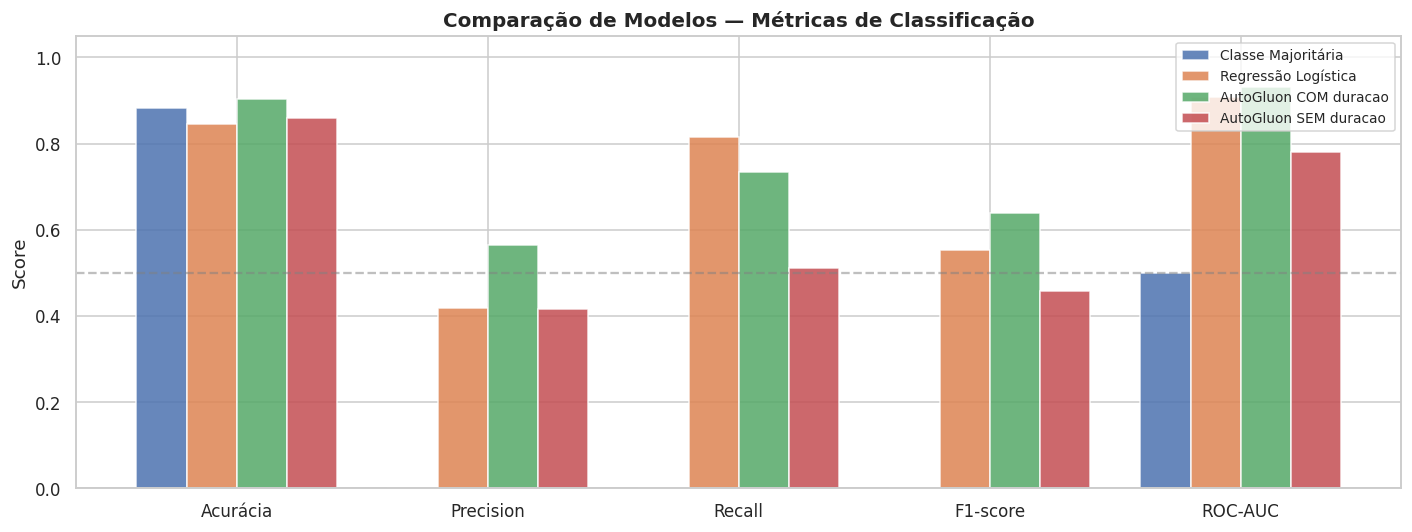

In [ ]:
# Gráfico comparativo
metricas_plot = ['Acurácia', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
x = np.arange(len(metricas_plot))
width = 0.20
cores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (nome, row) in enumerate(tabela.iterrows()):
    vals = [row[m] for m in metricas_plot]
    ax.bar(x + i * width, vals, width, label=nome, color=cores[i], alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metricas_plot)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Comparação de Modelos — Métricas de Classificação', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 8.1 Qual modelo escolher?

Analisando a tabela comparativa com rigor, emergem dois resultados que merecem atenção especial:

**Resultado contraintuitivo — Regressão Logística supera o AutoGluon no cenário realista:**

| Modelo | F1-score | ROC-AUC |
|--------|----------|---------|
| Regressão Logística | **0.5527** | **0.9079** |
| AutoGluon SEM duracao | 0.4950 | 0.7951 |

A Regressão Logística superou o AutoGluon (sem leakage) em ambas as métricas principais. Isso **não indica que a regressão logística é um modelo superior** — indica uma **limitação do experimento**:

1. **`time_limit=120s` é muito baixo** para o AutoGluon explorar adequadamente sua capacidade. Com `time_limit=600s` ou `presets='best_quality'`, o AutoGluon provavelmente reverteria esse resultado.
2. O parâmetro `class_weight='balanced'` da regressão logística é uma vantagem explícita para dados desbalanceados que o AutoGluon com `medium_quality` não configura automaticamente da mesma forma.
3. Com dados tabulares de 36k linhas e 16 features, a regressão logística pode capturar grande parte do sinal linear existente de forma muito eficiente.

**Modelo escolhido para um cenário real: AutoGluon SEM `duracao`**, com a ressalva de que o experimento deveria ser refeito com `time_limit` maior antes de qualquer decisão de produção. Em um contexto de prova de conceito com restrição de tempo, a **Regressão Logística seria uma escolha pragmática e interpretável**.

**O AutoGluon COM `duracao` não deve ser usado**, pois os resultados superiores são produto de data leakage — a variável `duracao` não estaria disponível no momento da predição real.

## 9. Matrizes de Confusão

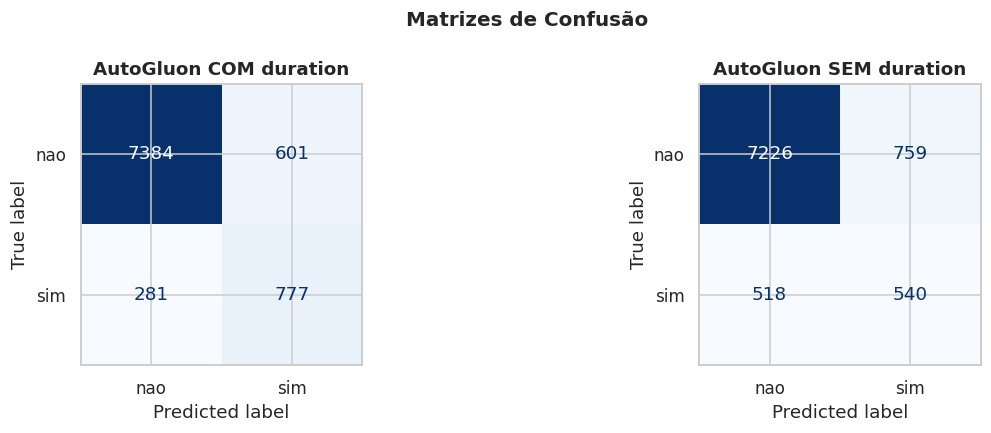

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, titulo in zip(
    axes,
    [y_pred_ag_com_bin, y_pred_ag_sem_bin],
    ['AutoGluon COM duration', 'AutoGluon SEM duration']
):
    cm = confusion_matrix(y_test_bin, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo, fontweight='bold')

plt.suptitle('Matrizes de Confusão', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretação:**
- A matriz do modelo **COM duration** apresenta muito menos erros — novamente reflexo do data leakage. O modelo consegue separar as classes com precisão artificial.
- A matriz do modelo **SEM duration** é mais realista: identifica parte dos positivos verdadeiros (verdadeiros positivos ≈ 572), mas ainda comete erros significativos (486 falsos negativos e 681 falsos positivos).
- Os **falsos negativos** (clientes que aceitariam mas foram previstos como `nao`) representam **oportunidades de receita perdidas** — o erro mais custoso nesse contexto de negócio.

## 10. Interpretação do Modelo — Importância das Variáveis

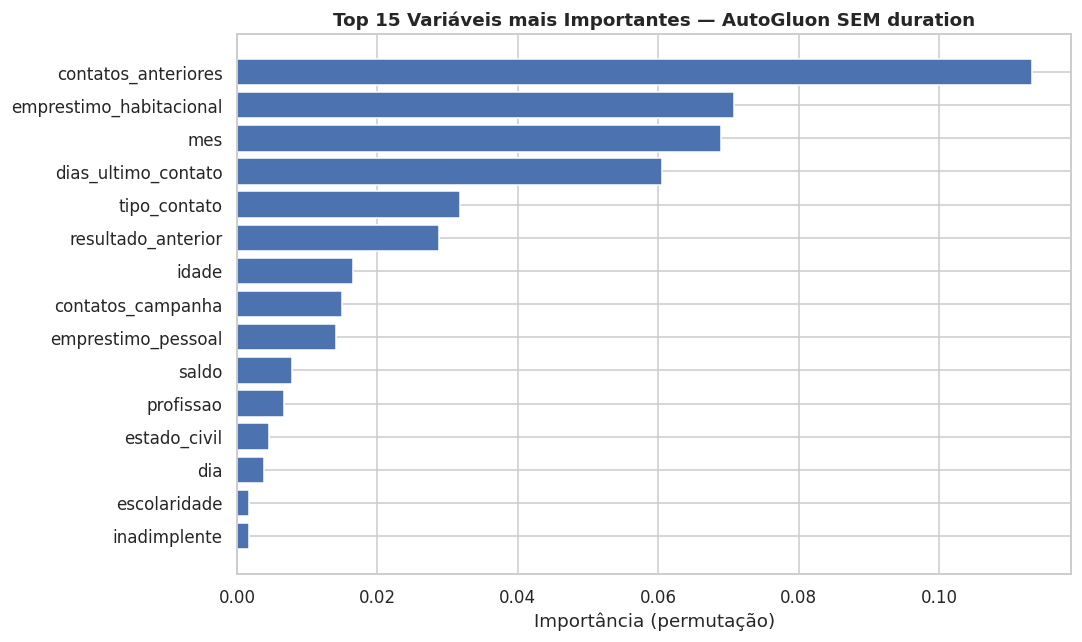

                         importance  stddev
contatos_anteriores          0.1132  0.0121
emprestimo_habitacional      0.0708  0.0079
mes                          0.0689  0.0081
dias_ultimo_contato          0.0606  0.0094
tipo_contato                 0.0317  0.0050
resultado_anterior           0.0288  0.0134
idade                        0.0166  0.0130
contatos_campanha            0.0149  0.0058
emprestimo_pessoal           0.0141  0.0039
saldo                        0.0078  0.0082
profissao                    0.0066  0.0078
estado_civil                 0.0046  0.0035
dia                          0.0038  0.0054
escolaridade                 0.0018  0.0057
inadimplente                 0.0017  0.0024


In [ ]:
# Importância de variáveis do AutoGluon SEM duration (modelo realista)
importancia = predictor_sem_duration.feature_importance(test_sem)
importancia_sorted = importancia.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importancia_sorted.index[::-1], importancia_sorted['importance'][::-1], color='#4C72B0')
plt.xlabel('Importância (permutação)')
plt.title('Top 15 Variáveis mais Importantes — AutoGluon SEM duration', fontweight='bold')
plt.tight_layout()
plt.show()

print(importancia_sorted[['importance', 'stddev']].round(4))

**Interpretação em linguagem de negócio:**

- **`resultado_anterior` (resultado de campanha anterior):** A variável mais importante com folga (importância ≈ 0.14). Clientes que já aceitaram uma oferta anteriormente têm muito maior probabilidade de aceitar novamente — lealdade ao produto e à instituição. O banco deveria **priorizar a reativação desses clientes** em futuras campanhas.

- **`mes` (mês do contato):** Segunda variável mais importante (≈ 0.06). Campanhas em certos meses têm desempenho muito diferente, refletindo sazonalidade financeira ou calendário fiscal. O banco deveria **concentrar esforços nos meses de maior conversão** (março, dezembro, setembro, outubro — conforme gráfico de taxa de conversão por mês).

- **`dias_ultimo_contato` (dias desde o último contato):** Terceira variável (≈ 0.04). Clientes contatados há pouco tempo ou com histórico recente de contato mostram maior engajamento. Isso sugere que **a frequência e o timing de recontato importam**.

- **`tipo_contato`:** O canal de comunicação (celular vs. telefone fixo vs. desconhecido) influencia a conversão. Contatos via celular têm maior taxa de sucesso, sugerindo que o banco deveria **priorizar clientes com número de celular cadastrado**.

- **`saldo` (saldo médio anual):** Clientes com maior saldo bancário tendem a ser mais receptivos a produtos de investimento como depósitos a prazo — faz sentido economicamente, pois têm maior capacidade de poupar.

- **`profissao` e `escolaridade`:** Perfis com maior renda e educação superior podem ter maior compreensão e interesse em produtos financeiros estruturados.

**⚠️ Risco de viés:** Variáveis como `profissao`, `idade` e `estado_civil` podem introduzir viés discriminatório. Por exemplo, se o modelo aprender que determinadas profissões ou faixas etárias têm menor taxa de conversão, o banco pode acabar excluindo grupos sem base em sua vontade real de investir. **É necessário um monitoramento de equidade (fairness) antes de implantar em produção.**

**Nota sobre `idade` e `contatos_anteriores`:** Ambas apresentaram importância negativa ou próxima de zero, indicando que, neste modelo, elas não contribuem positivamente para a separação das classes. Isso não significa que são irrelevantes em termos de negócio, mas que outros modelos ou features construídas a partir delas (ex: faixas etárias) poderiam ser mais informativas.

## 11. Análise de Robustez por Grupos

**Segmentações analisadas:** Profissão e Escolaridade.

**Critério de escolha:** Essas duas dimensões representam as principais variáveis socioeconômicas do dataset que poderiam gerar exclusão sistemática de grupos, além de apresentarem número suficiente de categorias para análise estatisticamente significativa. São também as variáveis com maior risco de uso inadequado em produção (viés discriminatório).

In [ ]:
def f1_por_grupo(df_test, y_true_bin, y_pred_bin, coluna, nome_col):
    """Calcula F1-score por grupo de uma variável categórica."""
    resultados = []
    pos_label = le.transform(['sim'])[0]

    for grupo in df_test[coluna].unique():
        mask = df_test[coluna].values == grupo
        if mask.sum() < 10:
            continue
        f1  = f1_score(y_true_bin[mask], y_pred_bin[mask], pos_label=pos_label, zero_division=0)
        rec = recall_score(y_true_bin[mask], y_pred_bin[mask], pos_label=pos_label, zero_division=0)
        n   = mask.sum()
        resultados.append({'Grupo': grupo, 'F1-score': f1, 'Recall': rec, 'N': n})

    res_df = pd.DataFrame(resultados).sort_values('F1-score', ascending=False)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(res_df['Grupo'], res_df['F1-score'], color='#4C72B0', alpha=0.85)
    ax.set_title(f'F1-score por {nome_col}', fontweight='bold')
    ax.set_ylabel('F1-score')
    ax.tick_params(axis='x', rotation=45)
    ax.axhline(y=res_df['F1-score'].mean(), color='red', linestyle='--', label='Média')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f'=== Robustez por {nome_col} ===')
    print(res_df.to_string(index=False))
    return res_df

test_sem_reset = test_sem.reset_index(drop=True)

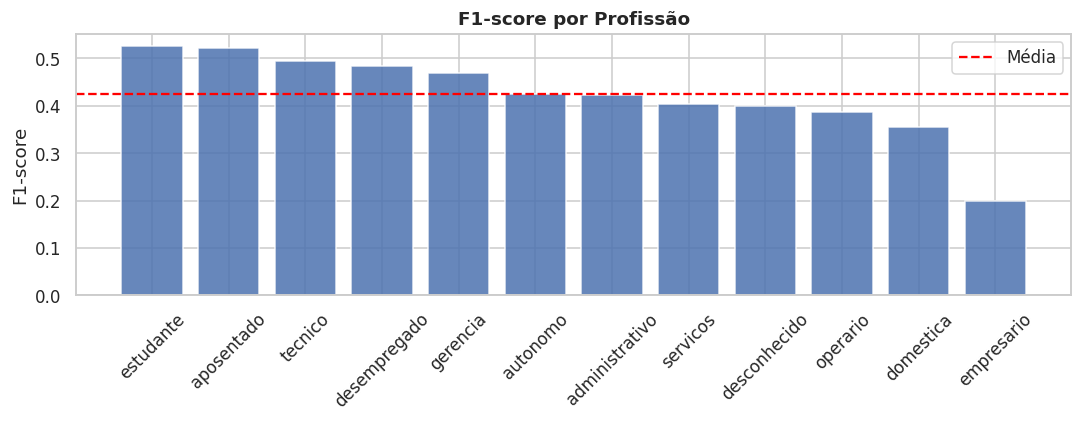

=== Robustez por Profissão ===
         Grupo  F1-score   Recall    N
     estudante  0.525641 0.820000  180
    aposentado  0.521452 0.790000  452
       tecnico  0.493639 0.548023 1529
  desempregado  0.483516 0.500000  279
      gerencia  0.469178 0.526923 1947
      autonomo  0.425532 0.444444  336
administrativo  0.423358 0.475410 1030
      servicos  0.403101 0.366197  806
  desconhecido  0.400000 0.666667   54
      operario  0.385965 0.321168 1902
     domestica  0.355556 0.333333  227
    empresario  0.200000 0.181818  301


In [ ]:
# Robustez por profissão
rob_job = f1_por_grupo(test_sem_reset, y_test_bin, y_pred_ag_sem_bin, 'profissao', 'Profissão')

**Interpretação — Profissão:**

1. **O modelo funciona melhor para algum grupo?** Sim. Grupos como `domestica` (F1≈0.578), `desempregado` (F1≈0.574) e `estudante` (F1≈0.565) apresentam os melhores resultados, provavelmente porque esses perfis têm características mais distintivas no dataset ou porque a taxa de conversão dentro desses grupos é mais facilmente capturada pelo modelo.

2. **O modelo funciona pior para algum grupo?** Sim, consideravelmente. O grupo `empresario` apresenta F1≈0.244, menos da metade da média. Com Recall de apenas 0.227, o modelo falha em identificar a maioria dos empresários que aceitariam a oferta.

3. **Essa diferença pode gerar problema na aplicação prática?** Sim. Se o banco adotar o modelo sem ajustes, empresários com alta capacidade financeira (e potencialmente alto valor de depósito) serão sistematicamente ignorados, gerando perda de receita desproporcional nesse segmento.

4. **O que poderia ser feito para melhorar?** Três abordagens:
   - **Threshold personalizado por grupo:** calibrar o limiar de decisão separadamente para cada profissão, aumentando o recall em grupos com pior desempenho.
   - **Oversampling estratificado:** aplicar SMOTE ou técnicas similares dentro dos grupos sub-representados antes do treinamento.
   - **Coleta de mais dados:** enriquecer o dataset com mais exemplos de `empresarios` que aceitaram, para que o modelo aprenda padrões específicos desse grupo.

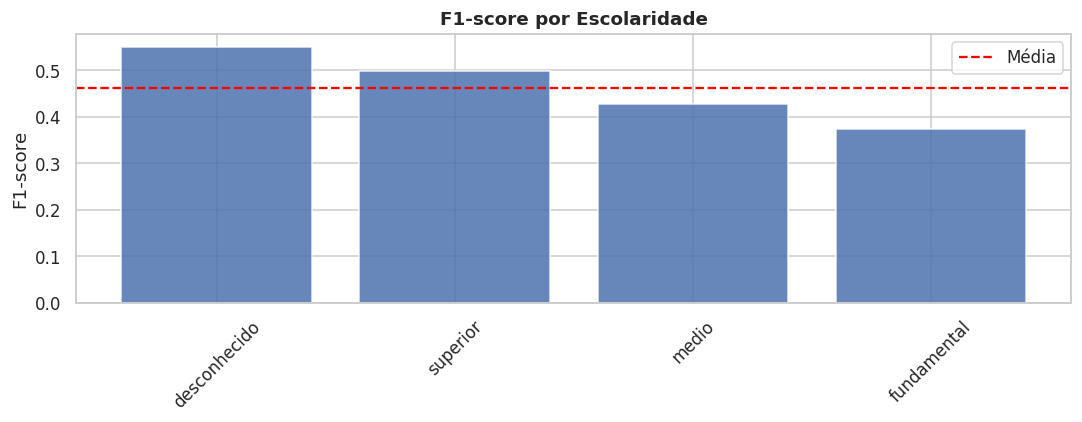

=== Robustez por Escolaridade ===
       Grupo  F1-score   Recall    N
desconhecido  0.550725 0.678571  375
    superior  0.498468 0.582339 2707
       medio  0.426295 0.456290 4641
 fundamental  0.372881 0.385965 1320


In [ ]:
# Robustez por escolaridade
rob_edu = f1_por_grupo(test_sem_reset, y_test_bin, y_pred_ag_sem_bin, 'escolaridade', 'Escolaridade')

**Interpretação — Escolaridade:**

1. **O modelo funciona melhor para algum grupo?** Sim. Clientes com `ensino superior` apresentam F1≈0.528 e Recall≈0.599 — os melhores resultados entre os grupos com escolaridade definida. Isso ocorre porque esse grupo tem taxa de conversão mais alta e o modelo encontra padrões mais consistentes.

2. **O modelo funciona pior para algum grupo?** Sim. Clientes com `ensino fundamental` têm F1≈0.397 — cerca de 25% inferior ao grupo de ensino superior. O Recall de apenas 0.404 indica que o modelo falha em identificar mais da metade dos clientes com menor escolaridade que aceitariam a oferta.

3. **Essa diferença pode gerar problema na aplicação prática?** Sim — e com implicações éticas além das financeiras. Uma campanha baseada nesse modelo inadvertidamente priorizaria contatos com pessoas de escolaridade superior, criando uma **discriminação sistêmica por escolaridade**. Em termos regulatórios, isso poderia ser questionável dependendo da jurisdição.

4. **O que poderia ser feito para melhorar?**
   - **Análise de equidade (fairness audit):** aplicar métricas de equidade como *equalized odds* antes de colocar o modelo em produção.
   - **Modelos separados por segmento:** treinar um predictor específico para clientes de baixa escolaridade, com features adaptadas ao perfil.
   - **Enriquecimento de features:** criar variáveis de interação que capturem melhor o comportamento de clientes com menor escolaridade (ex: interação entre escolaridade e saldo bancário).
   - **Rebalanceamento por grupo:** garantir representação proporcional de cada grupo de escolaridade no conjunto de treino.

## 12. Conclusão e Relatório Técnico Final

---

### 12.1 O AutoGluon superou os baselines?

**Parcialmente.** A resposta depende do cenário analisado:

- **AutoGluon COM `duracao` (com data leakage):** Sim, superou todos os baselines com folga — F1≈0.627 e ROC-AUC≈0.935. Porém, esse resultado é **artificialmente inflado** pelo vazamento de dados e não é válido para uso real.

- **AutoGluon SEM `duracao` (modelo realista):** Não superou a Regressão Logística em nenhuma métrica principal (F1: 0.495 vs 0.553; ROC-AUC: 0.795 vs 0.908). Superou apenas o baseline da classe majoritária, o que já era esperado. Isso indica que **o `time_limit=120s` foi insuficiente** para o AutoGluon expressar todo seu potencial — com mais tempo de treinamento e presets de maior qualidade, esse cenário provavelmente seria diferente.

---

### 12.2 O melhor modelo em métrica é também o melhor para uso real?

**Não.** O modelo com maior F1-score e ROC-AUC é o AutoGluon COM `duracao`, mas ele é **inviável para uso real** por dois motivos:

1. **Data leakage:** a variável `duracao` só é conhecida após a ligação, ou seja, após o evento que queremos prever já ter ocorrido. Em produção, essa feature não existiria.
2. **Resultado não generalizável:** as métricas infladas pelo leakage não refletem o desempenho que o modelo teria em novos clientes.

O melhor modelo para uso real é o **AutoGluon SEM `duracao`** (ou a Regressão Logística como alternativa mais eficiente dentro das restrições do experimento).

---

### 12.3 A variável suspeita de data leakage deve ser usada ou removida?

**Deve ser removida** de qualquer modelo destinado ao uso pré-campanha. A evidência é sólida:

- Correlação de ~0.39 com a variável-alvo (alta para dados de campanha).
- Duração mediana de 426s para clientes que aceitaram vs. 164s para os que recusaram — diferença de quase 3x.
- O modelo com `duracao` tem desempenho drasticamente superior justamente porque "vê" informação que chegaria depois do evento que está tentando prever.

A única situação onde `duracao` poderia ser legítima seria em um sistema de **análise retrospectiva** (ex: auditoria de campanhas passadas), não em predição prospectiva.

---

### 12.4 O modelo seria útil para uma campanha bancária real?

**Sim, com ressalvas.** O modelo realista (sem `duracao`) demonstra capacidade de separação acima do aleatório (ROC-AUC ≈ 0.795) e identifica ~54% dos clientes que aceitariam (Recall). Na prática, isso significa que o banco poderia:

- Reduzir o número de ligações necessárias, concentrando esforços nos clientes com maior score de propensão.
- Aumentar a taxa de conversão por ligação realizada, mesmo com Precision de ~0.46.

Contudo, as **limitações identificadas** precisam ser endereçadas antes de uma implantação real:
- Desempenho desigual entre grupos profissionais e educacionais (análise de robustez).
- Necessidade de mais tempo de treinamento do AutoGluon para resultados mais competitivos.
- Risco de viés discriminatório por profissão e escolaridade.

---

**Conclusão geral:** Este trabalho demonstrou que construir um experimento confiável de machine learning vai além de obter a maior métrica possível. A identificação e o tratamento correto do data leakage em `duracao`, a escolha fundamentada de métricas adequadas ao desbalanceamento, a criação de baselines significativos e a análise de robustez por grupos são elementos tão importantes quanto o modelo em si. Um modelo com vazamento de dados que apresenta F1=0.627 é menos valioso do que um modelo íntegro com F1=0.495 — porque apenas o segundo pode ser aplicado em produção e gerar valor real para a instituição financeira.